<a href="https://colab.research.google.com/github/y284/biological-particle-detector/blob/main/quickstart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quickstart: BPD

**Estimated time to complete:** 7 minutes

## Learning Goals
* Learn about BPD model inputs and outputs
* Run BPD model inference on a tomogram

## Introduction


BPD (Biological Particle Detector) is a deep learning model that localizes macromolecular particles in cryo-ET denoised tomograms through 3D segmentation and coordinate extraction. Using a 3D CNN architecture, it processes input tomograms to generate binary masks, identify connected components, and output particle centroids (x,y,z). This quickstart demonstrates detection of ribosomes and other complexes in a tomogram.


## Setup

If using Google Colab, connect to the T4 GPU runtime hosted for free by Google Colab using the dropdown menu in the upper right hand corner of this notebook.

"Runtime" -> "Change runtime type".

Using a GPU significantly speeds up running model inference, but CPU compute can also be used.

## Clone Repository

To run BPD in Google Colab or your local machine, start by cloning the BPD repo and navigate to the newly created BPD folder using the commands below. The folder will also be present in the file management system in Google Colab which is accessible by clicking the folder icon on the left hand side bar of this notebook.

In [ ]:
!git clone https://github.com/y284/biological-particle-detector.git
%cd /content/biological-particle-detector

Cloning into 'biological-particle-detector'...
remote: Enumerating objects: 37, done.
remote: Counting objects: 100% (37/37), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 37 (delta 15), reused 27 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (37/37), 5.02 MiB | 7.63 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/biological-particle-detector


## Install Packages
**Estimated installation time**: 3 minutes

Install the following packages:

* mlflow
* connected-components-3d
* pandas
* torch
* copick

**Note:** If running in Colab, you will need to restart session after installation.

In [ ]:
!pip install -r requirements.txt
!pip install "copick[all]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.7/24.7 MB 98.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 91.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.2/821.2 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 94.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 134.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 96.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/5

  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of boto3 to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of boto3 to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.5/53.5 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.0/278.0 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Reset the directory after restarting the session.

In [ ]:
%cd /content/biological-particle-detector

/content/biological-particle-detector


## Run Model Inference
**Estimated time**: 3 minutes

### Package MLflow model

In [ ]:
# Let's package our mlflow model
!python package.py

2025/07/14 19:50:52 INFO mlflow.pyfunc: Validating input example against model signature
MLflow model packaged at: mlflow_model


### Download tomograms

In [ ]:
# Here we will download some tomograms

import zarr

import copick
from copick.ops.get import get_tomograms

project = copick.from_czcdp_datasets([10440], "/tmp/test")
tomograms = get_tomograms(project, voxel_size=10.012, tomo_type="wbp-denoised-denoiset-ctfdeconv", parallel=True)

  0%|          | 0/7 [00:00<?, ?runs/s]

### Predict particle coordinates (run inference)

In [ ]:
# Let's use the first tomogram to run inference on

tomo = tomograms[0]
zarr_store = tomo.zarr()
zarr_array = zarr.open(zarr_store)['0']
print(f"Tomogram {tomo.tomo_type} of run {tomo.voxel_spacing.run.name} shape: {zarr_array.shape}")


Tomogram wbp-denoised-denoiset-ctfdeconv of run 16465 shape: (184, 630, 630)


**Model inference should take around 2min**

In [ ]:
import mlflow

#load model and predict
model = mlflow.pyfunc.load_model("mlflow_model")
predictions = model.predict(zarr_array[:])

NumExpr defaulting to 2 threads.


## Model Output and Visualization

The model outputs coordinates of detected particles, so let's do some visualization.


In [ ]:
for col in ["z","y","x"]:
  predictions[col] = predictions[col].map(lambda x: int(x))

predictions.head()

,x,y,z,particle_type
0,460,215,46,apo-ferritin
1,567,342,53,apo-ferritin
2,546,150,53,apo-ferritin
3,475,202,55,apo-ferritin
4,150,286,61,apo-ferritin


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

def visualize_particles(volume, coordinates, crop_size=64, particle_type=""):
    """
    Visualize 64x64 regions around each (y,x) point in their respective Z slices.

    Parameters:
    - volume: 3D numpy array (Z, Y, X)
    - coordinates: List of tuples (z, y, x)
    - crop_size: Size of the square region to crop (default 64)
    """

    # Determine the number of slices to display
    n_slices = len(coordinates)

    # Create a figure with subplots
    fig, axes = plt.subplots(1, n_slices, figsize=(5 * n_slices, 5))
    if n_slices == 1:
        axes = [axes]  # Ensure axes is iterable even for single slice

    # Set the main title for the figure (particle type)
    fig.suptitle(f'Particle Type: {particle_type}', fontsize=16, y=1.05)

    for i, (z,y,x)  in enumerate(coordinates):
        # Extract the YX slice
        yx_slice = volume[z, :, :]
        slice_height, slice_width = yx_slice.shape


        # Calculate crop boundaries
        half_size = crop_size // 2
        y_start = max(0, y - half_size)
        y_end = min(slice_height, y + half_size)
        x_start = max(0, x - half_size)
        x_end = min(slice_width, x + half_size)

        # Handle cases where the crop goes out of bounds
        # Adjust crop size if near the edge
        if y_end - y_start < crop_size or x_end - x_start < crop_size:
            # If near the edge, pad with zeros or reflect
            cropped = np.zeros((crop_size, crop_size), dtype=yx_slice.dtype)
            y_slice = slice(y_start, y_end)
            x_slice = slice(x_start, x_end)
            cropped_y_start = half_size - (y - y_start)
            cropped_y_end = cropped_y_start + (y_end - y_start)
            cropped_x_start = half_size - (x - x_start)
            cropped_x_end = cropped_x_start + (x_end - x_start)
            cropped[cropped_y_start:cropped_y_end, cropped_x_start:cropped_x_end] = yx_slice[y_slice, x_slice]
        else:
            cropped = yx_slice[y - half_size:y + half_size, x - half_size:x + half_size]

        # Display the cropped region
        ax = axes[i] if n_slices > 1 else axes
        ax.imshow(cropped, cmap='gray', origin='lower')
        ax.set_title(f'Z = {z}, Center (Y,X): ({y},{x})')
        ax.plot(crop_size // 2, crop_size // 2, 'ro', markersize=5)  # Mark the center

    plt.tight_layout()
    plt.show()

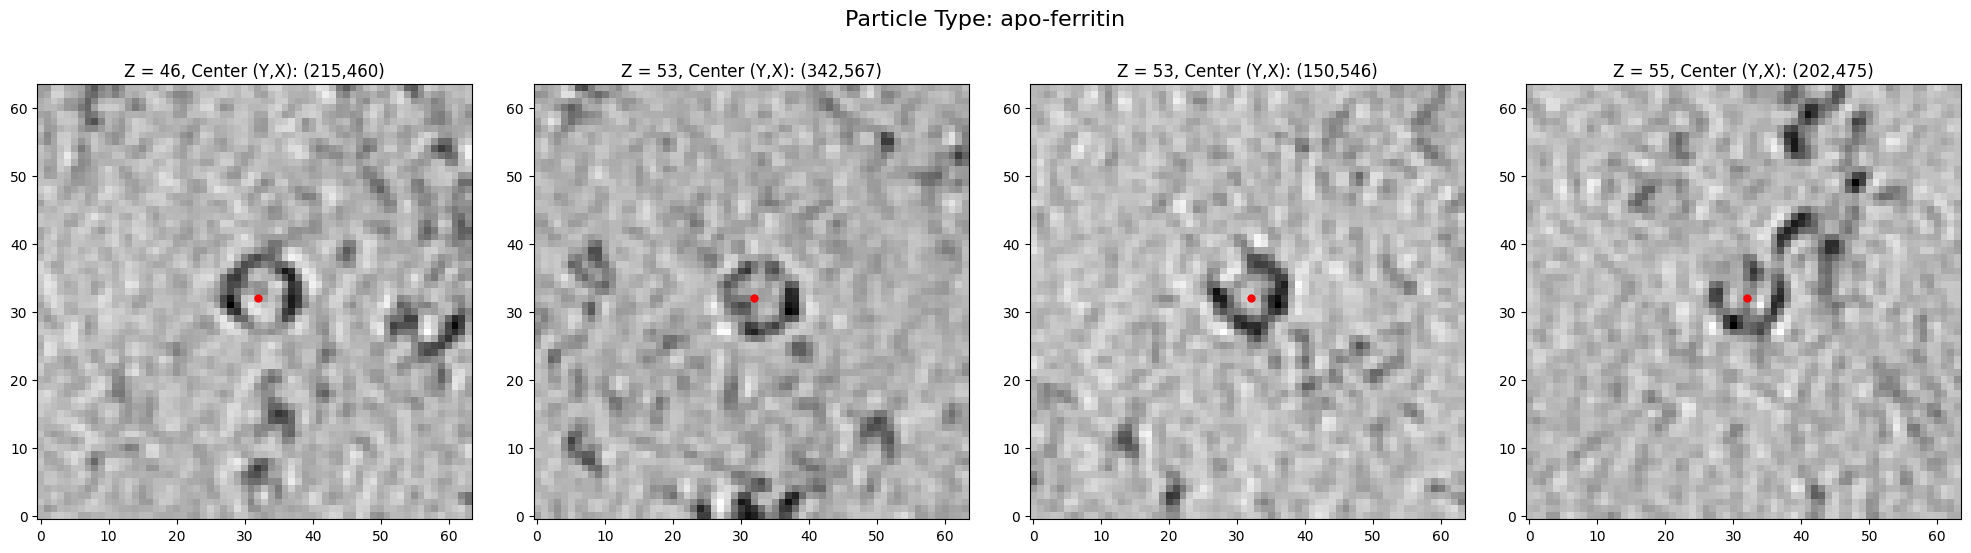

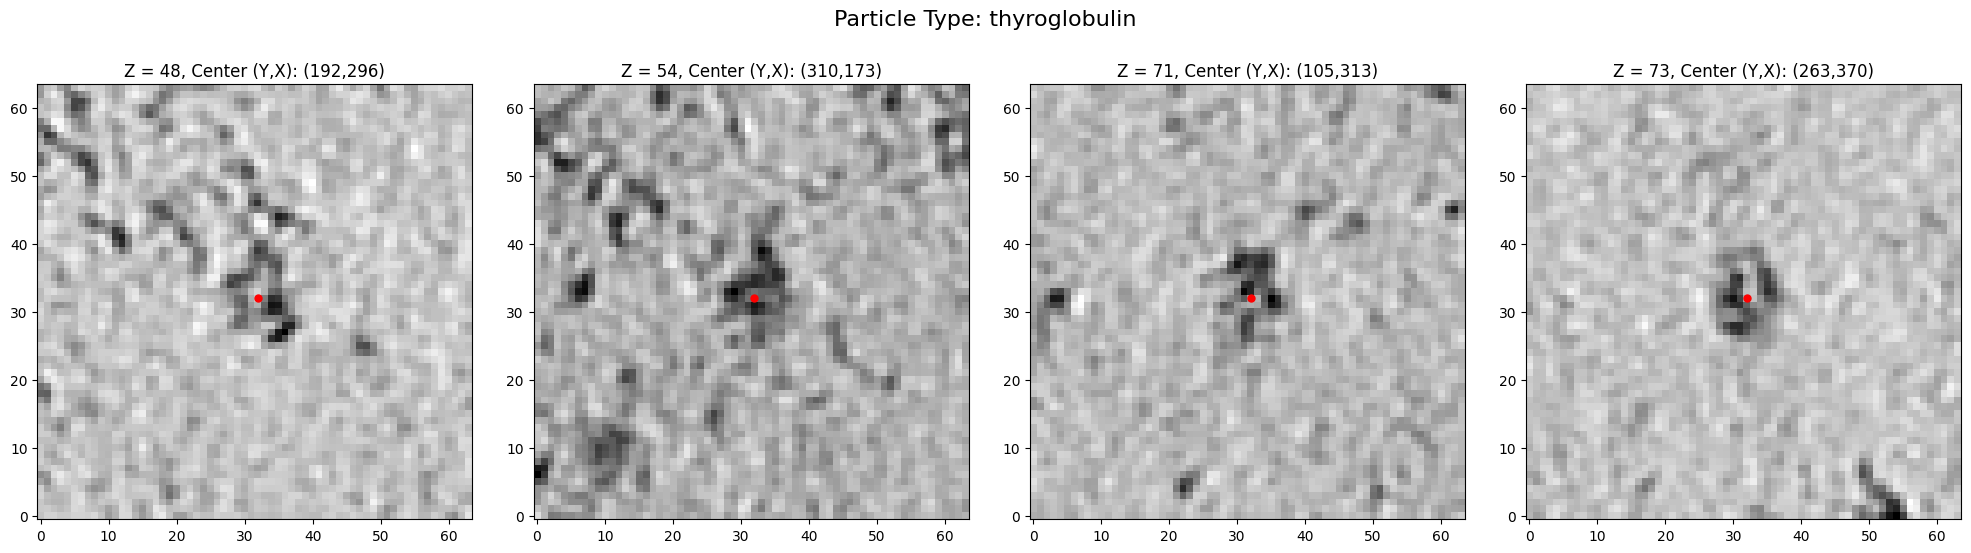

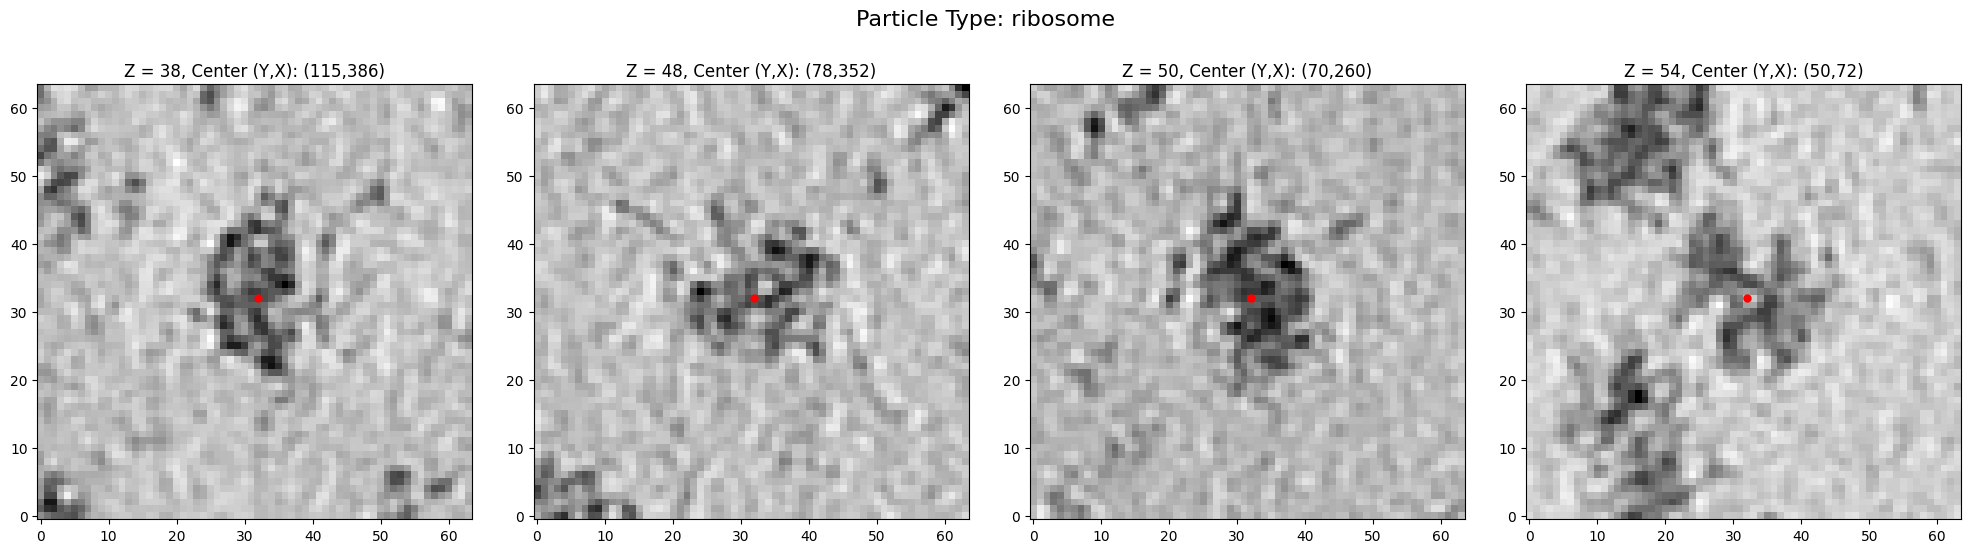

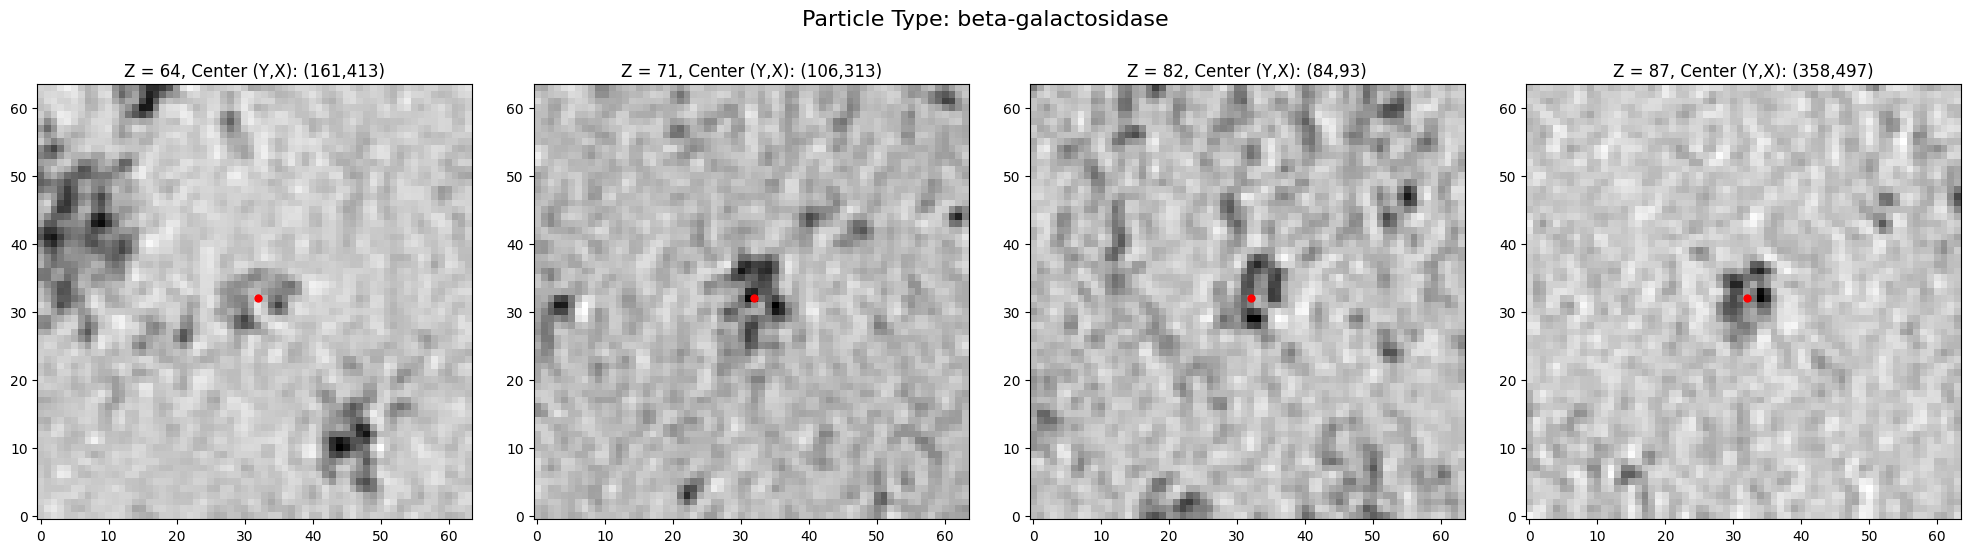

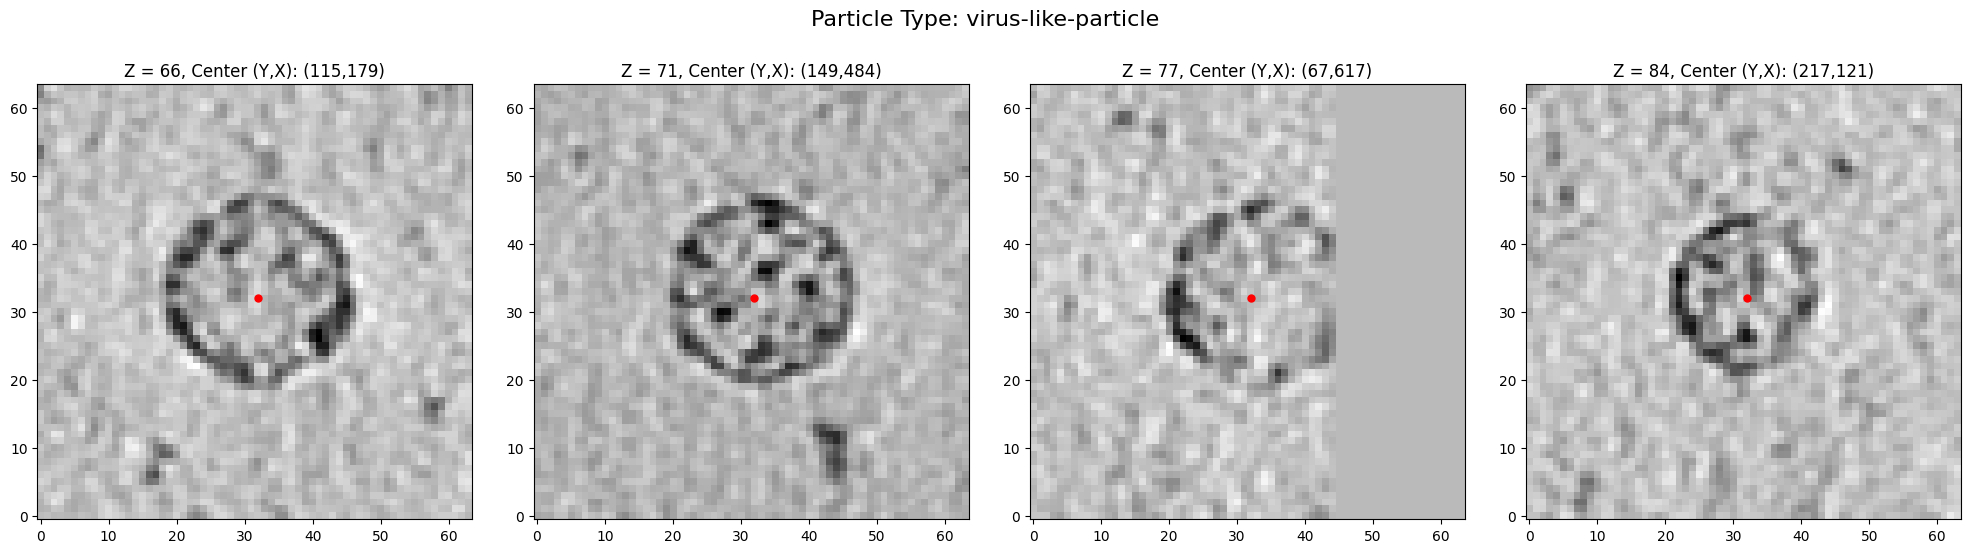

In [ ]:
particle_types = [
  'apo-ferritin',
  'thyroglobulin',
  'ribosome',
  'beta-galactosidase',
  'virus-like-particle'
]

for particle_type in particle_types:
  to_visualize = predictions[predictions["particle_type"] == particle_type]

  if len(to_visualize) == 0:
    continue

  num_samples = min(len(to_visualize), 4)
  to_visualize = to_visualize.iloc[:num_samples]
  coordinates = np.array(to_visualize[["z","y","x"]])

  visualize_particles(zarr_array[:], coordinates, particle_type = particle_type)


## Contact

For issues with this quickstart please contact Youssef Ouertani at ouertaniyoussef@yahoo.fr



## Responsible Use

We are committed to advancing the responsible development and use of artificial intelligence. Please follow our [Acceptable Use Policy](https://virtualcellmodels.cziscience.com/acceptable-use-policy) when engaging with our services.